<a href="https://colab.research.google.com/github/hima879/aiml/blob/main/hima879/aiml/blob/master/practice/Cohort_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a random seed so you get the same results as me
np.random.seed(42)

# Create fake transaction data
dates = pd.date_range('2025-01-01', '2026-01-01', freq='D')
data = {
    'user_id': np.random.randint(1, 200, size=500),
    'transaction_date': np.random.choice(dates, size=500),
    'revenue': np.round(np.random.uniform(10, 100, size=500), 2)
}
df = pd.DataFrame(data)

# Sort by date so it's tidy
df = df.sort_values('transaction_date').reset_index(drop=True)
print(df.head(25))

    user_id transaction_date  revenue
0       137       2025-01-01    57.20
1        86       2025-01-01    47.60
2        87       2025-01-01    87.01
3        75       2025-01-01    69.73
4        86       2025-01-03    83.42
5       118       2025-01-04    76.92
6       175       2025-01-04    78.42
7        39       2025-01-05    25.45
8       104       2025-01-05    46.17
9        29       2025-01-05    41.23
10      197       2025-01-06    44.48
11       90       2025-01-06    88.06
12       63       2025-01-07    40.17
13       58       2025-01-07    23.85
14        8       2025-01-08    94.85
15       95       2025-01-08    66.33
16       68       2025-01-08    12.39
17       90       2025-01-09    56.70
18       21       2025-01-10    23.89
19       96       2025-01-10    67.01
20       92       2025-01-12    69.87
21      130       2025-01-12    28.45
22      127       2025-01-12    31.49
23       99       2025-01-13    54.63
24      124       2025-01-13    40.79


In [6]:
# Convert date to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Create a column for the transaction month (e.g., '2025-01')
df['transaction_month'] = df['transaction_date'].dt.to_period('M')

# Find the FIRST purchase month for each user
df['cohort_month'] = df.groupby('user_id')['transaction_month'].transform('min')

# See the result
print(df[['user_id', 'transaction_month', 'cohort_month']].head(20))

    user_id transaction_month cohort_month
0       137           2025-01      2025-01
1        86           2025-01      2025-01
2        87           2025-01      2025-01
3        75           2025-01      2025-01
4        86           2025-01      2025-01
5       118           2025-01      2025-01
6       175           2025-01      2025-01
7        39           2025-01      2025-01
8       104           2025-01      2025-01
9        29           2025-01      2025-01
10      197           2025-01      2025-01
11       90           2025-01      2025-01
12       63           2025-01      2025-01
13       58           2025-01      2025-01
14        8           2025-01      2025-01
15       95           2025-01      2025-01
16       68           2025-01      2025-01
17       90           2025-01      2025-01
18       21           2025-01      2025-01
19       96           2025-01      2025-01


In [9]:
# Calculate the period difference (in months)
df['cohort_period'] = (df['transaction_month'].dt.year - df['cohort_month'].dt.year) * 12 + \
                      (df['transaction_month'].dt.month - df['cohort_month'].dt.month)

# Add 1 so Period 0 becomes Period 1 (easier to read)
df['cohort_period'] = df['cohort_period'] + 1

print(df[['user_id', 'cohort_month', 'cohort_period']].head())

   user_id cohort_month  cohort_period
0      137      2025-01              1
1       86      2025-01              1
2       87      2025-01              1
3       75      2025-01              1
4       86      2025-01              1


In [10]:
# Group data
cohort_data = df.groupby(['cohort_month', 'cohort_period'])['user_id'].nunique().reset_index()

# Pivot the table (Rows = Cohorts, Columns = Periods)
cohort_pivot = cohort_data.pivot(index='cohort_month', columns='cohort_period', values='user_id')

print(cohort_pivot)

cohort_period    1    2    3    4    5    6     7     8    9    10   11   12
cohort_month                                                                
2025-01        38.0  7.0  7.0  6.0  5.0  5.0   8.0   9.0  8.0  8.0  8.0  8.0
2025-02        30.0  7.0  6.0  4.0  9.0  3.0  10.0  10.0  4.0  6.0  8.0  NaN
2025-03        22.0  3.0  5.0  2.0  5.0  4.0   6.0   3.0  3.0  3.0  NaN  NaN
2025-04        19.0  4.0  4.0  2.0  4.0  1.0   NaN   3.0  1.0  NaN  NaN  NaN
2025-05        19.0  5.0  2.0  5.0  2.0  6.0   NaN   4.0  1.0  NaN  NaN  NaN
2025-06        11.0  1.0  3.0  1.0  3.0  NaN   2.0   NaN  NaN  NaN  NaN  NaN
2025-07        13.0  3.0  2.0  3.0  NaN  4.0   NaN   NaN  NaN  NaN  NaN  NaN
2025-08        11.0  NaN  2.0  2.0  3.0  NaN   NaN   NaN  NaN  NaN  NaN  NaN
2025-09         9.0  4.0  2.0  NaN  NaN  NaN   NaN   NaN  NaN  NaN  NaN  NaN
2025-10         1.0  NaN  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  NaN  NaN
2025-11         5.0  1.0  NaN  NaN  NaN  NaN   NaN   NaN  NaN  NaN  NaN  NaN

In [11]:
# Get the size of each cohort (Period 1)
cohort_sizes = cohort_pivot[1]

# Divide all columns by the cohort size
retention_matrix = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# Round it to 1 decimal place
retention_matrix = retention_matrix.round(1)

print(retention_matrix)

cohort_period     1     2     3     4     5     6     7     8     9     10  \
cohort_month                                                                 
2025-01        100.0  18.4  18.4  15.8  13.2  13.2  21.1  23.7  21.1  21.1   
2025-02        100.0  23.3  20.0  13.3  30.0  10.0  33.3  33.3  13.3  20.0   
2025-03        100.0  13.6  22.7   9.1  22.7  18.2  27.3  13.6  13.6  13.6   
2025-04        100.0  21.1  21.1  10.5  21.1   5.3   NaN  15.8   5.3   NaN   
2025-05        100.0  26.3  10.5  26.3  10.5  31.6   NaN  21.1   5.3   NaN   
2025-06        100.0   9.1  27.3   9.1  27.3   NaN  18.2   NaN   NaN   NaN   
2025-07        100.0  23.1  15.4  23.1   NaN  30.8   NaN   NaN   NaN   NaN   
2025-08        100.0   NaN  18.2  18.2  27.3   NaN   NaN   NaN   NaN   NaN   
2025-09        100.0  44.4  22.2   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2025-10        100.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2025-11        100.0  20.0   NaN   NaN   NaN   NaN   NaN   NaN  

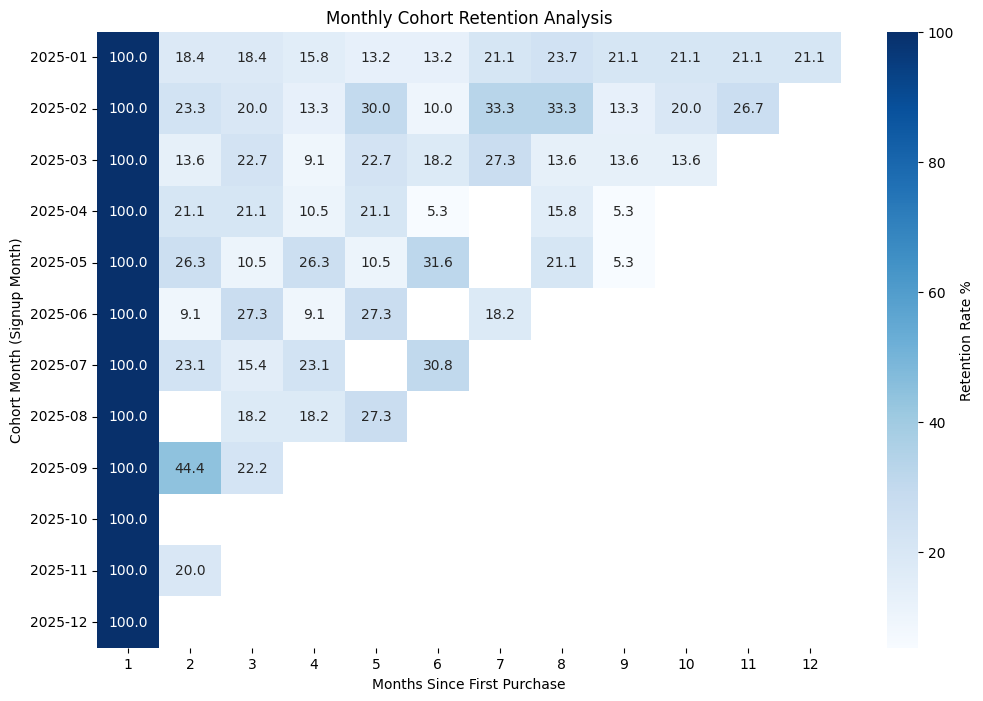

In [12]:
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Retention Rate %'})
plt.title('Monthly Cohort Retention Analysis')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month (Signup Month)')
plt.show()